# Observations

We have historic time series for the three crops in the study – maize, beans and sorghum. For 1999-2022 we have official data from El Salvador, and for 1961-2023 we have FAO data. The data gives the production (total weight grown), area cultivated and yield (production per hectare) for each crop for the country.

We choose to work with production in this analysis. While yield is perhaps a more intuitive measure of the impact of droughts, production has the advantage that we can sum it across different departments when we run risk calculations later.

To work with production observations, however, we will need to scale the historic production to match today's cultivated areas so that they are comparable.

This notebook reads in historic data, visualizes them, harmonizes them, and then calculates production anomalies, which will be used in the calibration. 

In [1]:
from pathlib import Path

# -----------------------------------------------
# Set up paths to data
# -----------------------------------------------

OBSERVATIONS_DIR = "../data/observations/"
OBSERVATIONS_FILES = {
    "maize": "observations_raw_maize.csv",
    "beans": "observations_raw_beans.csv",
    "sorghum": "observations_raw_sorghum.csv"
}
observations_filepaths = {
    crop: Path(OBSERVATIONS_DIR) / filename for crop, filename in OBSERVATIONS_FILES.items()
}

# How far back do we think the observations are representative?
# The more years we have, the more data we have to fit the model, but at some point the economic and agricultural 
# systems become too different from the present day to be useful for calibration, especially given El Salvador's history.
# This is a subjective choice, but we can test sensitivity to this parameter by changing it and re-running the notebook.
START_YEAR = 1972
END_YEAR = 2023

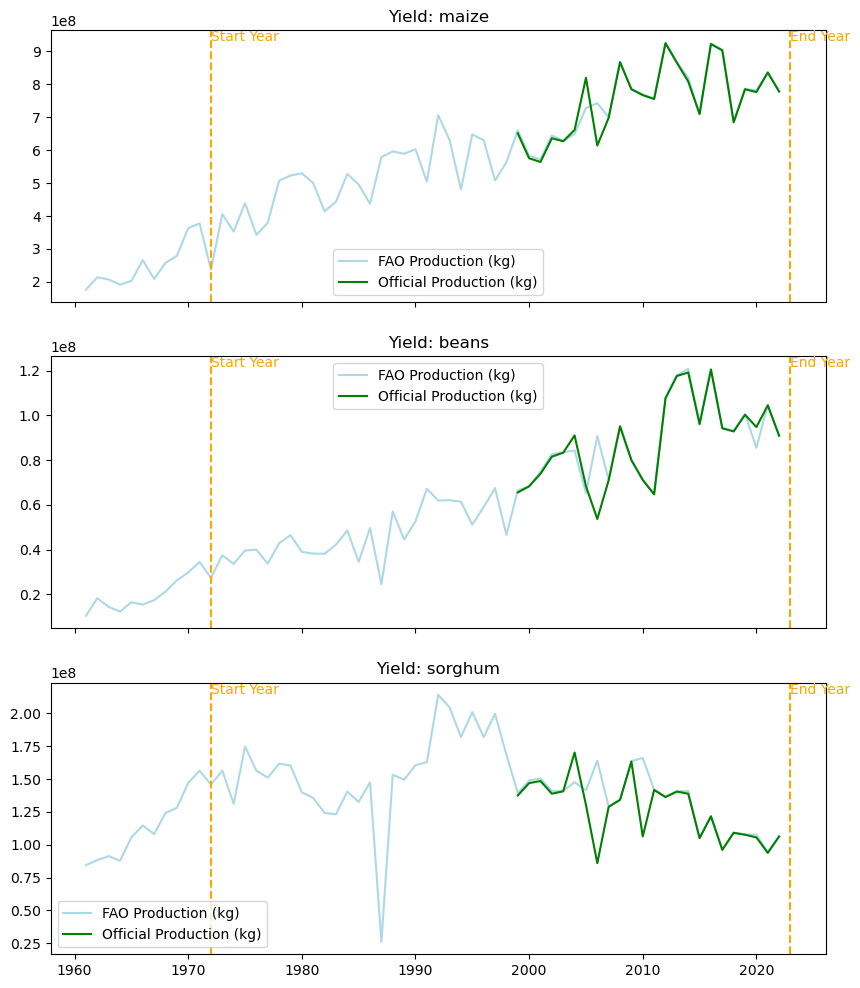

In [2]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# -----------------------------------------------
# Read and plot the raw observations
# -----------------------------------------------

obs = {crop: pd.read_csv(filepath) for crop, filepath in observations_filepaths.items()}

VARIABLE = "Production"  # Which variable are we building results from?
UNIT = "kg"
OFFICIAL_COL = f"Official {VARIABLE} ({UNIT})"
FAO_COL = f"FAO {VARIABLE} ({UNIT})"

# Plot the two time series we have for each crop:
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
for i, (crop, obs_crop) in enumerate(obs.items()):
    axes[i].plot(obs_crop['Year'], obs_crop[FAO_COL], label=FAO_COL, color="lightblue")
    axes[i].plot(obs_crop['Year'], obs_crop[OFFICIAL_COL], label=OFFICIAL_COL, color="green")
    # add vertical lines to indicate the start and end years we are using for calibration
    axes[i].axvline(START_YEAR, color="orange", linestyle="--")
    axes[i].text(START_YEAR, axes[i].get_ylim()[1], "Start Year", color="orange", verticalalignment="top")
    axes[i].axvline(END_YEAR, color="orange", linestyle="--")
    axes[i].text(END_YEAR, axes[i].get_ylim()[1], "End Year", color="orange", verticalalignment="top")
    axes[i].set_title(f"Yield: {crop}")
    axes[i].legend()


While the plot time series mostly agree, there are some differences in the overlapping years. The FAO data claims to report the official country statistics and should agree. Without more in-depth research we con't explain this: it could be due to one dataset revising statistics with more information in later years, or due to reporting periods (since crops may have more than one growing season), or some other reason.

We choose to take the official statistics when available, and use the FAO data in other years.

In [3]:
# -----------------------------------------------
# Harmonize the observations
# -----------------------------------------------

# Use official data when we have it, and otherwise use FAO data
for crop, obs_crop in obs.items():
    harmonized = [x if not pd.isna(x) else y for x, y in zip(obs_crop[OFFICIAL_COL], obs_crop[FAO_COL])]
    harmonized_col = f"Harmonized {VARIABLE} ({UNIT})"
    obs_crop[harmonized_col] = harmonized

# Trim the data to the years we want to use for calibration
for crop, obs_crop in obs.items():
    obs_crop = obs_crop[(obs_crop['Year'] >= START_YEAR) & (obs_crop['Year'] <= END_YEAR)]
    obs[crop] = obs_crop

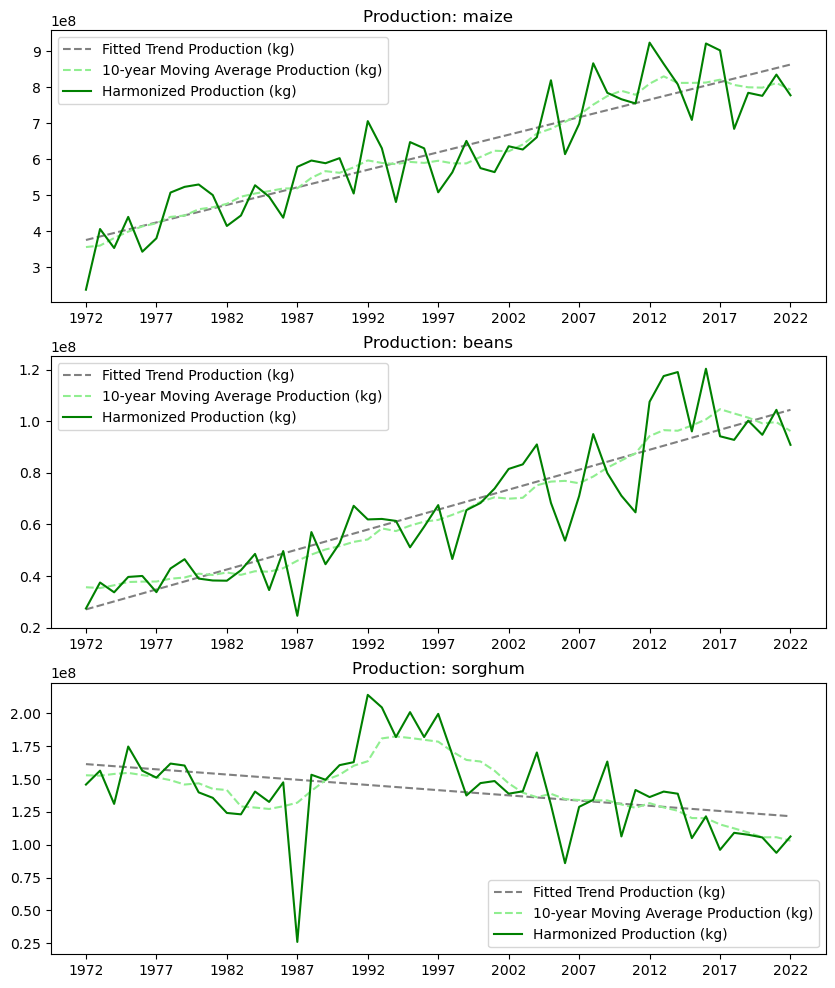

In [4]:
# -----------------------------------------------
# Calculate productivity anomalies
# -----------------------------------------------

fig, axes = plt.subplots(3, 1, figsize=(10, 12))

for i, (crop, obs_crop) in enumerate(obs.items()):
    harmonized_col = f"Harmonized {VARIABLE} ({UNIT})"

    # Fit a linear model to the harmonized column
    trend, intercept = np.polyfit(obs_crop['Year'], obs_crop[harmonized_col], 1)
    trend_values = trend * obs_crop['Year'] + intercept
    trend_col = f"Fitted Trend {VARIABLE} ({UNIT})"
    obs_crop[trend_col] = trend_values

    # Calculate 10-year moving average of the harmonized column centered on the current year
    # We won't use this, but it's another option for calculating the size of anomalies
    moving_avg_col = f"10-year Moving Average {VARIABLE} ({UNIT})"
    obs_crop[moving_avg_col] = obs_crop[harmonized_col].rolling(window=10, min_periods=1, center=True).mean()

    # Calculate absoute yield anomaly relative to the average
    anomaly = obs_crop[harmonized_col] - obs_crop[trend_col]
    anomaly_col = f"{VARIABLE} Anomaly ({UNIT})"
    obs_crop[anomaly_col] = anomaly
    
    # Calculate relative anomaly
    anomaly_fraction = anomaly / obs_crop[trend_col]
    anomaly_fraction_col = f"{VARIABLE} Anomaly (fraction)"
    obs_crop[anomaly_fraction_col] = anomaly_fraction

    # Use the trend to scale historic values to 2023 levels
    obs_crop[f"{VARIABLE} change to present (fraction)"] = obs_crop[trend_col].iloc[-1] / obs_crop[trend_col]
    obs_crop[f"Present-equivalent {VARIABLE} ({UNIT})"] = obs_crop[harmonized_col] * obs_crop[f"{VARIABLE} change to present (fraction)"]
    obs_crop[f"Present-equivalent {VARIABLE} anomaly ({UNIT})"] = obs_crop[anomaly_col] * obs_crop[f"{VARIABLE} change to present (fraction)"]

    # Plot
    axes[i].plot(obs_crop['Year'], obs_crop[trend_col], label=trend_col, color="grey", linestyle="--")
    axes[i].plot(obs_crop['Year'], obs_crop[moving_avg_col], label=moving_avg_col, color="lightgreen", linestyle="--")
    axes[i].plot(obs_crop['Year'], obs_crop[harmonized_col], label=harmonized_col, color="green")
    axes[i].set_xticks(np.arange(obs_crop['Year'].min(), obs_crop['Year'].max() + 1, 5))
    axes[i].set_xticklabels(np.arange(int(obs_crop['Year'].min()), int(obs_crop['Year'].max()) + 1, 5))
    axes[i].legend()
    axes[i].set_title(f"{VARIABLE}: {crop}")


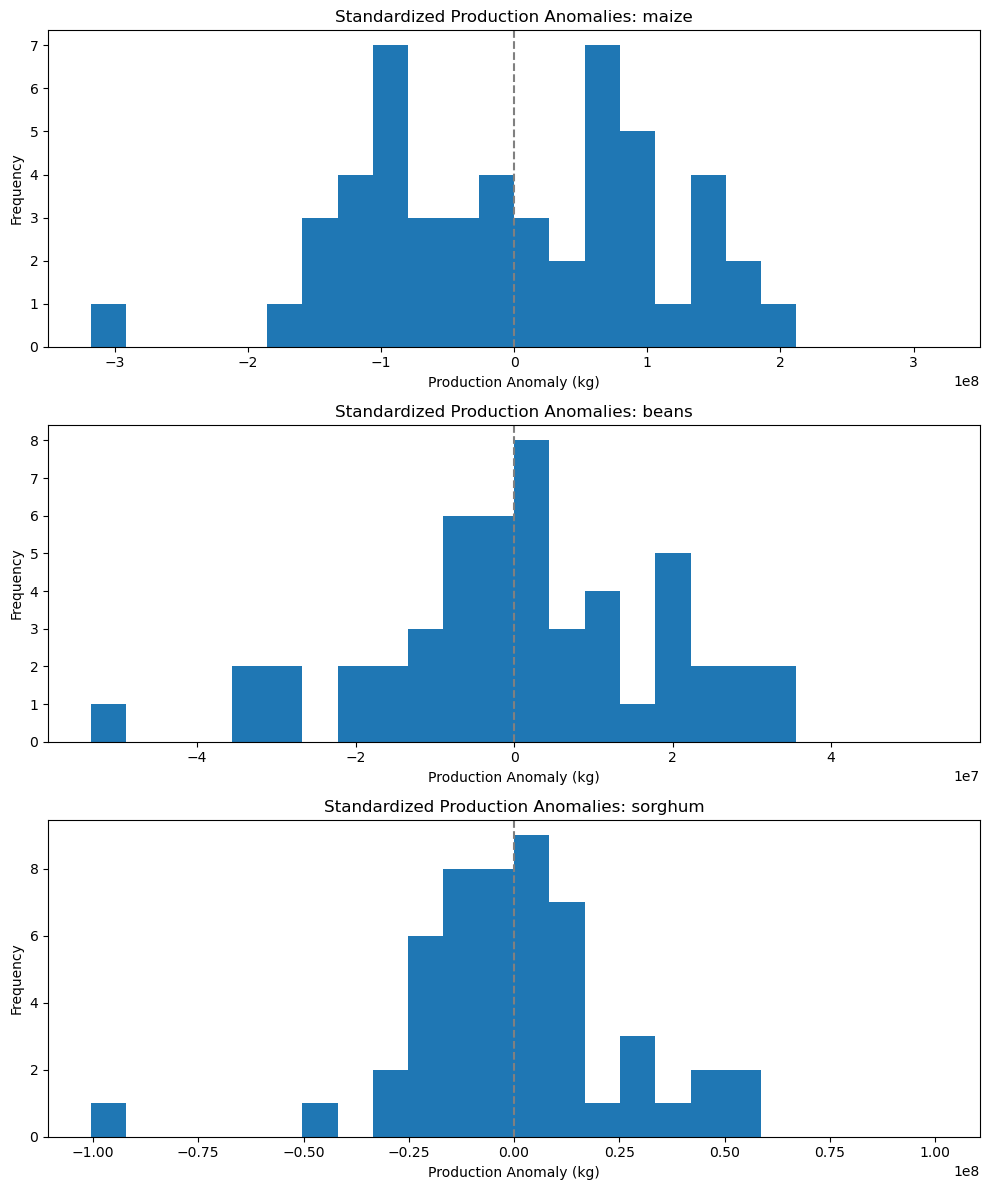

In [5]:
# Plot histogram of anomalies
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
for i, (crop, obs_crop) in enumerate(obs.items()):
    anomaly_col = f"Present-equivalent {VARIABLE} anomaly ({UNIT})"
    # set bins so that 0 is a bin edge
    max_anomaly = max(abs(obs_crop[anomaly_col]))
    bins = np.linspace(-max_anomaly, max_anomaly, 25)
    axes[i].hist(obs_crop[anomaly_col], bins=bins)
    # add vertical line at 0
    axes[i].axvline(0, color="grey", linestyle="--")
    axes[i].set_title(f"Standardized {VARIABLE} Anomalies: {crop}")
    axes[i].set_xlabel(f"{VARIABLE} Anomaly ({UNIT})")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [6]:
# Now do some subjective identification of drought events:
n_years_data = obs_crop['Year'].max() - obs_crop['Year'].min() + 1

# Filter to events with a more than 10% drop
anomaly_fraction_col = f"{VARIABLE} Anomaly (fraction)"
for crop, obs_crop in obs.items():
    obs_crop["drought"] = obs_crop[anomaly_fraction_col] < -0.1

# Rank the anomalies and use these to estimate return periods
anomaly_col = f"Present-equivalent {VARIABLE} anomaly ({UNIT})"
for crop, obs_crop in obs.items():
    # obs_crop = obs_crop.sort_values(by=anomaly_col, ascending=True)
    obs_crop['Rank'] = obs_crop[anomaly_col].rank(ascending=True)
    obs_crop['Return Period (years)'] = n_years_data / obs_crop['Rank']
    obs_crop.loc[~obs_crop['drought'], 'Return Period (years)'] = np.nan
    obs[crop] = obs_crop
    display(obs_crop[['Year', anomaly_col, anomaly_fraction_col, 'drought', 'Rank', 'Return Period (years)']])

,Year,Present-equivalent Production anomaly (kg),Production Anomaly (fraction),drought,Rank,Return Period (years)
11,1972.0,-3.180749e+08,-0.368580,True,1.0,51.000000
12,1973.0,4.656582e+07,0.053960,False,31.0,NaN
13,1974.0,-9.136188e+07,-0.105869,True,12.0,4.250000
14,1975.0,7.464178e+07,0.086494,False,36.0,NaN
15,1976.0,-1.492522e+08,-0.172951,True,4.0,12.750000
16,1977.0,-8.971626e+07,-0.103962,True,14.0,3.642857
17,1978.0,1.460814e+08,0.169277,False,46.0,NaN
18,1979.0,1.546630e+08,0.179221,False,48.0,NaN
19,1980.0,1.453154e+08,0.168389,False,45.0,NaN
20,1981.0,6.914535e+07,0.080124,False,35.0,NaN


,Year,Present-equivalent Production anomaly (kg),Production Anomaly (fraction),drought,Rank,Return Period (years)
11,1972,1.381926e+06,0.013228,False,27.0,NaN
12,1973,3.245662e+07,0.310682,False,51.0,NaN
13,1974,1.226872e+07,0.117439,False,39.0,NaN
14,1975,2.621887e+07,0.250973,False,47.0,NaN
15,1976,2.132791e+07,0.204155,False,44.0,NaN
16,1977,-3.134444e+06,-0.030004,False,21.0,NaN
17,1978,1.892643e+07,0.181168,False,41.0,NaN
18,1979,2.381837e+07,0.227995,False,46.0,NaN
19,1980,-1.145065e+06,-0.010961,False,24.0,NaN
20,1981,-6.925484e+06,-0.066292,False,14.0,NaN


,Year,Present-equivalent Production anomaly (kg),Production Anomaly (fraction),drought,Rank,Return Period (years)
11,1972.0,-1.175586e+07,-0.096583,False,17.0,NaN
12,1973.0,-3.194656e+06,-0.026246,False,23.0,NaN
13,1974.0,-2.187399e+07,-0.179711,True,8.0,6.375000
14,1975.0,1.207170e+07,0.099178,False,41.0,NaN
15,1976.0,-1.439277e+06,-0.011825,False,26.0,NaN
16,1977.0,-4.901653e+06,-0.040271,False,19.0,NaN
17,1978.0,4.015333e+06,0.032989,False,33.0,NaN
18,1979.0,3.481165e+06,0.028600,False,31.0,NaN
19,1980.0,-1.191415e+07,-0.097884,False,16.0,NaN
20,1981.0,-1.463773e+07,-0.120260,True,15.0,3.400000


In [7]:
# -----------------------------------------------
# Save to file
# -----------------------------------------------

for crop, obs_crop in obs.items():
    print(f"Saving observations for {crop}...")
    obs_crop = obs_crop[[
        "Year",
        f"Official {VARIABLE} ({UNIT})",
        f"FAO {VARIABLE} ({UNIT})",
        f"Harmonized {VARIABLE} ({UNIT})",
        f"Fitted Trend {VARIABLE} ({UNIT})",
        f"10-year Moving Average {VARIABLE} ({UNIT})",
        f"{VARIABLE} Anomaly ({UNIT})",
        f"{VARIABLE} Anomaly (fraction)",
        f"Present-equivalent {VARIABLE} ({UNIT})",
        f"Present-equivalent {VARIABLE} anomaly ({UNIT})",
        f"Return Period (years)"
    ]]
    obs_crop = obs_crop.round(2)  # Round all values to 2 decimal places - nothing needs to be more precise than this, and it makes it easier to read
    obs[crop] = obs_crop
    obs_crop.to_csv(Path(OBSERVATIONS_DIR) / f"observations_{crop}.csv", index=False)
    display(obs_crop)


Saving observations for maize...


,Year,Official Production (kg),FAO Production (kg),Harmonized Production (kg),Fitted Trend Production (kg),10-year Moving Average Production (kg),Production Anomaly (kg),Production Anomaly (fraction),Present-equivalent Production (kg),Present-equivalent Production anomaly (kg),Return Period (years)
11,1972.0,NaN,236782000.0,236782000.0,3.749990e+08,3.553454e+08,-1.382170e+08,-0.37,5.448996e+08,-3.180749e+08,51.00
12,1973.0,NaN,405520000.0,405520000.0,3.847586e+08,3.594108e+08,2.076144e+07,0.05,9.095404e+08,4.656582e+07,NaN
13,1974.0,NaN,352751000.0,352751000.0,3.945181e+08,3.804874e+08,-4.176706e+07,-0.11,7.716127e+08,-9.136188e+07,4.25
14,1975.0,NaN,439245000.0,439245000.0,4.042776e+08,3.982724e+08,3.496743e+07,0.09,9.376163e+08,7.464178e+07,NaN
15,1976.0,NaN,342429000.0,342429000.0,4.140371e+08,4.128386e+08,-7.160808e+07,-0.17,7.137223e+08,-1.492522e+08,12.75
16,1977.0,NaN,379738000.0,379738000.0,4.237966e+08,4.215466e+08,-4.405859e+07,-0.10,7.732583e+08,-8.971626e+07,3.64
17,1978.0,NaN,506947000.0,506947000.0,4.335561e+08,4.392684e+08,7.339090e+07,0.17,1.009056e+09,1.460814e+08,NaN
18,1979.0,NaN,522767000.0,522767000.0,4.433156e+08,4.430282e+08,7.945139e+07,0.18,1.017638e+09,1.546630e+08,NaN
19,1980.0,NaN,529368000.0,529368000.0,4.530751e+08,4.604761e+08,7.629288e+07,0.17,1.008290e+09,1.453154e+08,NaN
20,1981.0,NaN,499919000.0,499919000.0,4.628346e+08,4.660896e+08,3.708437e+07,0.08,9.321199e+08,6.914535e+07,NaN


Saving observations for beans...


,Year,Official Production (kg),FAO Production (kg),Harmonized Production (kg),Fitted Trend Production (kg),10-year Moving Average Production (kg),Production Anomaly (kg),Production Anomaly (fraction),Present-equivalent Production (kg),Present-equivalent Production anomaly (kg),Return Period (years)
11,1972,NaN,27402000,2.740200e+07,2.704426e+07,3.564520e+07,357744.21,0.01,1.058509e+08,1381926.26,NaN
12,1973,NaN,37476000,3.747600e+07,2.859275e+07,3.532817e+07,8883250.04,0.31,1.369256e+08,32456616.95,NaN
13,1974,NaN,33681000,3.368100e+07,3.014124e+07,3.641243e+07,3539755.86,0.12,1.167377e+08,12268724.80,NaN
14,1975,NaN,39643000,3.964300e+07,3.168974e+07,3.767600e+07,7953261.69,0.25,1.306878e+08,26218866.34,NaN
15,1976,NaN,40024000,4.002400e+07,3.323823e+07,3.782311e+07,6785767.51,0.20,1.257969e+08,21327912.24,NaN
16,1977,NaN,33743000,3.374300e+07,3.478673e+07,3.786720e+07,-1043726.66,-0.03,1.013345e+08,-3134443.92,NaN
17,1978,NaN,42918000,4.291800e+07,3.633522e+07,3.894500e+07,6582779.16,0.18,1.233954e+08,18926433.00,NaN
18,1979,NaN,46521000,4.652100e+07,3.788372e+07,3.942150e+07,8637284.99,0.23,1.282873e+08,23818366.77,NaN
19,1980,NaN,39000000,3.900000e+07,3.943221e+07,4.091100e+07,-432209.19,-0.01,1.033239e+08,-1145065.10,NaN
20,1981,NaN,38264000,3.826400e+07,4.098070e+07,4.040220e+07,-2716703.36,-0.07,9.754348e+07,-6925483.56,NaN


Saving observations for sorghum...


,Year,Official Production (kg),FAO Production (kg),Harmonized Production (kg),Fitted Trend Production (kg),10-year Moving Average Production (kg),Production Anomaly (kg),Production Anomaly (fraction),Present-equivalent Production (kg),Present-equivalent Production anomaly (kg),Return Period (years)
11,1972.0,NaN,145820000.0,1.458200e+08,1.614094e+08,1.528966e+08,-1.558944e+07,-0.10,1.099616e+08,-1.175586e+07,NaN
12,1973.0,NaN,156400000.0,1.564000e+08,1.606156e+08,1.525972e+08,-4.215596e+06,-0.03,1.185228e+08,-3.194656e+06,NaN
13,1974.0,NaN,131100000.0,1.311000e+08,1.598218e+08,1.539139e+08,-2.872176e+07,-0.18,9.984346e+07,-2.187399e+07,6.38
14,1975.0,NaN,174800000.0,1.748000e+08,1.590279e+08,1.547134e+08,1.577208e+07,0.10,1.337891e+08,1.207170e+07,NaN
15,1976.0,NaN,156363000.0,1.563630e+08,1.582341e+08,1.530653e+08,-1.871077e+06,-0.01,1.202782e+08,-1.439277e+06,NaN
16,1977.0,NaN,151100000.0,1.511000e+08,1.574402e+08,1.513301e+08,-6.340237e+06,-0.04,1.168158e+08,-4.901654e+06,NaN
17,1978.0,NaN,161814000.0,1.618140e+08,1.566464e+08,1.491681e+08,5.167603e+06,0.03,1.257328e+08,4.015333e+06,NaN
18,1979.0,NaN,160310000.0,1.603100e+08,1.558526e+08,1.458428e+08,4.457442e+06,0.03,1.251986e+08,3.481165e+06,NaN
19,1980.0,NaN,139881000.0,1.398810e+08,1.550587e+08,1.467808e+08,-1.517772e+07,-0.10,1.098033e+08,-1.191415e+07,NaN
20,1981.0,NaN,135713000.0,1.357130e+08,1.542649e+08,1.425616e+08,-1.855188e+07,-0.12,1.070797e+08,-1.463773e+07,3.40
